# 🧮 unitary
**Obtiene y visualiza la matriz unitaria de un circuito cuántico.**

Usa `qiskit.quantum_info.Operator` para extraer la matriz $U \in \mathbb{C}^{2^n \times 2^n}$
correspondiente a cualquier `QuantumCircuit`.

> ⚠️ **Convención Qiskit (little-endian)**: `q[0]` es el bit *menos* significativo.
> La fila/columna $k$ corresponde al estado base $|k\rangle$ leído de derecha a izquierda.
>
> ⚠️ El circuito **no puede tener mediciones** antes de calcular la unitaria.
> Usa `remove_final_measurements()` si es necesario.

## 📦 1. Instalación de dependencias

In [1]:
try:
    import qiskit
    print(f"✅ Qiskit {qiskit.__version__} ya instalado")
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install",
                           "qiskit", "qiskit-aer", "pylatexenc", "-q"])
    print("✅ Qiskit instalado correctamente")

✅ Qiskit 2.4.1 ya instalado


## 📚 2. Imports

In [2]:
import json
import math
from shared import *
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Operator
from qiskit.circuit.library import (
    RZGate, RYGate, XGate, CXGate, HGate, ZGate, SGate, TGate,
)

print("✅ Imports OK")

✅ Imports OK


---
## 🧪 5. Demos

### 5a — Bell State `|Φ+⟩`
Matriz 4×4. La unitaria del Bell State es la del CNOT·(H⊗I).

In [3]:
qc_bell = QuantumCircuit(2, name="bell")
qc_bell.h(0)
qc_bell.cx(0, 1)

U_bell = get_unitary(qc_bell)

print("🔔 Bell State — Matriz unitaria (numpy):")
print(np.round(U_bell, 4))
print()

print("🔔 Bell State — Tabla módulo∠fase:")
print_unitary(U_bell)
print()

# Verificar que es unitaria: U†·U ≈ I
identity_check = np.allclose(U_bell @ U_bell.conj().T, np.eye(4))
print(f"✅ U†·U ≈ I: {identity_check}")

🔔 Bell State — Matriz unitaria (numpy):
[[ 0.7071+0.j  0.7071+0.j  0.    +0.j  0.    +0.j]
 [ 0.    +0.j  0.    +0.j  0.7071+0.j -0.7071+0.j]
 [ 0.    +0.j  0.    +0.j  0.7071+0.j  0.7071+0.j]
 [ 0.7071+0.j -0.7071+0.j  0.    +0.j  0.    +0.j]]

🔔 Bell State — Tabla módulo∠fase:
              |00⟩             |01⟩             |10⟩             |11⟩      
───────────────────────────────────────────────────────────────────────────
|00⟩   +0.7071∠  +0.00°  +0.7071∠  +0.00°     0              0         
|01⟩      0              0           +0.7071∠  +0.00°  +0.7071∠+180.00°
|10⟩      0              0           +0.7071∠  +0.00°  +0.7071∠  +0.00°
|11⟩   +0.7071∠  +0.00°  +0.7071∠+180.00°     0              0         

✅ U†·U ≈ I: True


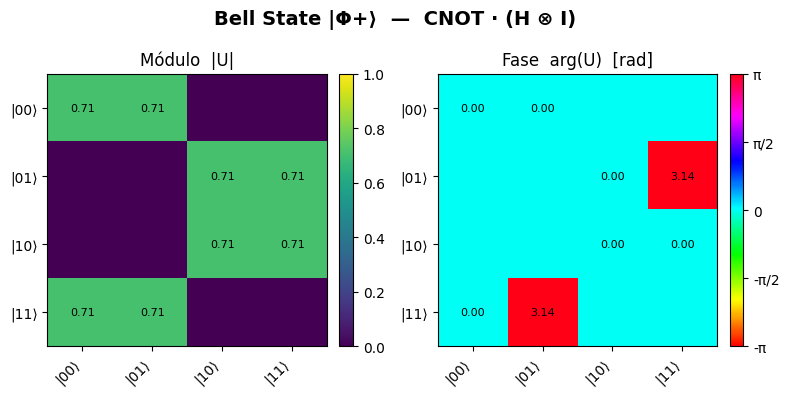

In [4]:
plot_unitary(U_bell, title="Bell State |Φ+⟩  —  CNOT · (H ⊗ I)")

### 5b — Compuertas de 1 qubit: H, X, Z, S, T, Rz(π/4), Ry(π/3)

In [5]:
single_gates = {
    "H":        lambda qc: qc.h(0),
    "X":        lambda qc: qc.x(0),
    "Z":        lambda qc: qc.z(0),
    "S":        lambda qc: qc.s(0),
    "T":        lambda qc: qc.t(0),
    "Rz(π/4)": lambda qc: qc.rz(math.pi / 4, 0),
    "Ry(π/3)": lambda qc: qc.ry(math.pi / 3, 0),
}

for gate_name, apply in single_gates.items():
    qc = QuantumCircuit(1)
    apply(qc)
    U = get_unitary(qc)
    print(f"── {gate_name} ──────────────────────")
    print(np.round(U, 4))
    print()

── H ──────────────────────
[[ 0.7071+0.j  0.7071+0.j]
 [ 0.7071+0.j -0.7071+0.j]]

── X ──────────────────────
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]

── Z ──────────────────────
[[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]

── S ──────────────────────
[[1.+0.j 0.+0.j]
 [0.+0.j 0.+1.j]]

── T ──────────────────────
[[1.    +0.j     0.    +0.j    ]
 [0.    +0.j     0.7071+0.7071j]]

── Rz(π/4) ──────────────────────
[[0.9239-0.3827j 0.    +0.j    ]
 [0.    +0.j     0.9239+0.3827j]]

── Ry(π/3) ──────────────────────
[[ 0.866+0.j -0.5  +0.j]
 [ 0.5  +0.j  0.866+0.j]]



### 5c — Desde un archivo JSON (json2quantum)
Carga `bell_recovered.json` y obtiene su unitaria.

In [6]:
JSON_FILE = "bell_recovered.json"   # ← cambia aquí para otro nivel

with open(JSON_FILE, "r") as f:
    data = json.load(f)

qc_from_json = parse_json_to_circuit(data)
U_from_json  = get_unitary(qc_from_json)

print(f"📄 Unitaria de '{JSON_FILE}':")
print(np.round(U_from_json, 4))
print()

# Comparar con la unitaria calculada directamente
print(f"🔍 ¿Igual a U_bell? {np.allclose(U_from_json, U_bell, atol=1e-8)}")

📄 Unitaria de 'bell_recovered.json':
[[ 0.7071+0.j  0.7071+0.j  0.    +0.j  0.    +0.j]
 [ 0.    +0.j  0.    +0.j  0.7071+0.j -0.7071+0.j]
 [ 0.    +0.j  0.    +0.j  0.7071+0.j  0.7071+0.j]
 [ 0.7071+0.j -0.7071+0.j  0.    +0.j  0.    +0.j]]

🔍 ¿Igual a U_bell? True


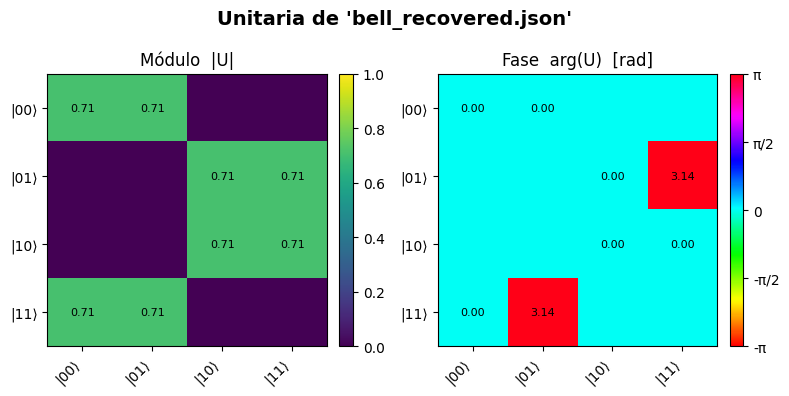

In [7]:
plot_unitary(U_from_json, title=f"Unitaria de '{JSON_FILE}'")

### 5d — `circuito.json` (4 qubits → matriz 16×16)

In [8]:
with open("circuito.json", "r") as f:
    data6 = json.load(f)

qc1   = parse_json_to_circuit(data6)
U1    = get_unitary(qc1)

print(f"⚛️  circuito.json — {U1.shape[0]}×{U1.shape[1]} unitaria")
print("Módulos (valores ~0 truncados a 0):")
print(np.round(U1, 4))
#print(np.where(np.abs(U6) < 1e-8, 0, np.round(np.abs(U6), 4)))

⚛️  circuito.json — 16×16 unitaria
Módulos (valores ~0 truncados a 0):
[[ 0.8536-0.3536j  0.    +0.j     -0.3536+0.1464j  0.    +0.j
   0.    +0.j      0.    +0.j      0.    +0.j      0.    +0.j
   0.    +0.j      0.    +0.j      0.    +0.j      0.    +0.j
   0.    +0.j      0.    +0.j      0.    +0.j      0.    +0.j    ]
 [ 0.    +0.j      0.    +0.j      0.    +0.j      0.    +0.j
   0.    +0.j      0.3536-0.1464j  0.    +0.j      0.8536-0.3536j
   0.    +0.j      0.    +0.j      0.    +0.j      0.    +0.j
   0.    +0.j      0.    +0.j      0.    +0.j      0.    +0.j    ]
 [ 0.3536-0.1464j  0.    +0.j      0.8536-0.3536j  0.    +0.j
   0.    +0.j      0.    +0.j      0.    +0.j      0.    +0.j
   0.    +0.j      0.    +0.j      0.    +0.j      0.    +0.j
   0.    +0.j      0.    +0.j      0.    +0.j      0.    +0.j    ]
 [ 0.    +0.j      0.    +0.j      0.    +0.j      0.    +0.j
   0.    +0.j      0.8536-0.3536j  0.    +0.j     -0.3536+0.1464j
   0.    +0.j      0.    +0.j      0. 

In [9]:
dim=U1.shape[0]
n_qubits = int(np.log2(dim))
qc = QuantumCircuit(n_qubits)

qc.unitary(U1, range(n_qubits))
qc.draw()


┌──────────┐
q_0: ┤0         ├
     │          │
q_1: ┤1         ├
     │  Unitary │
q_2: ┤2         ├
     │          │
q_3: ┤3         ├
     └──────────┘

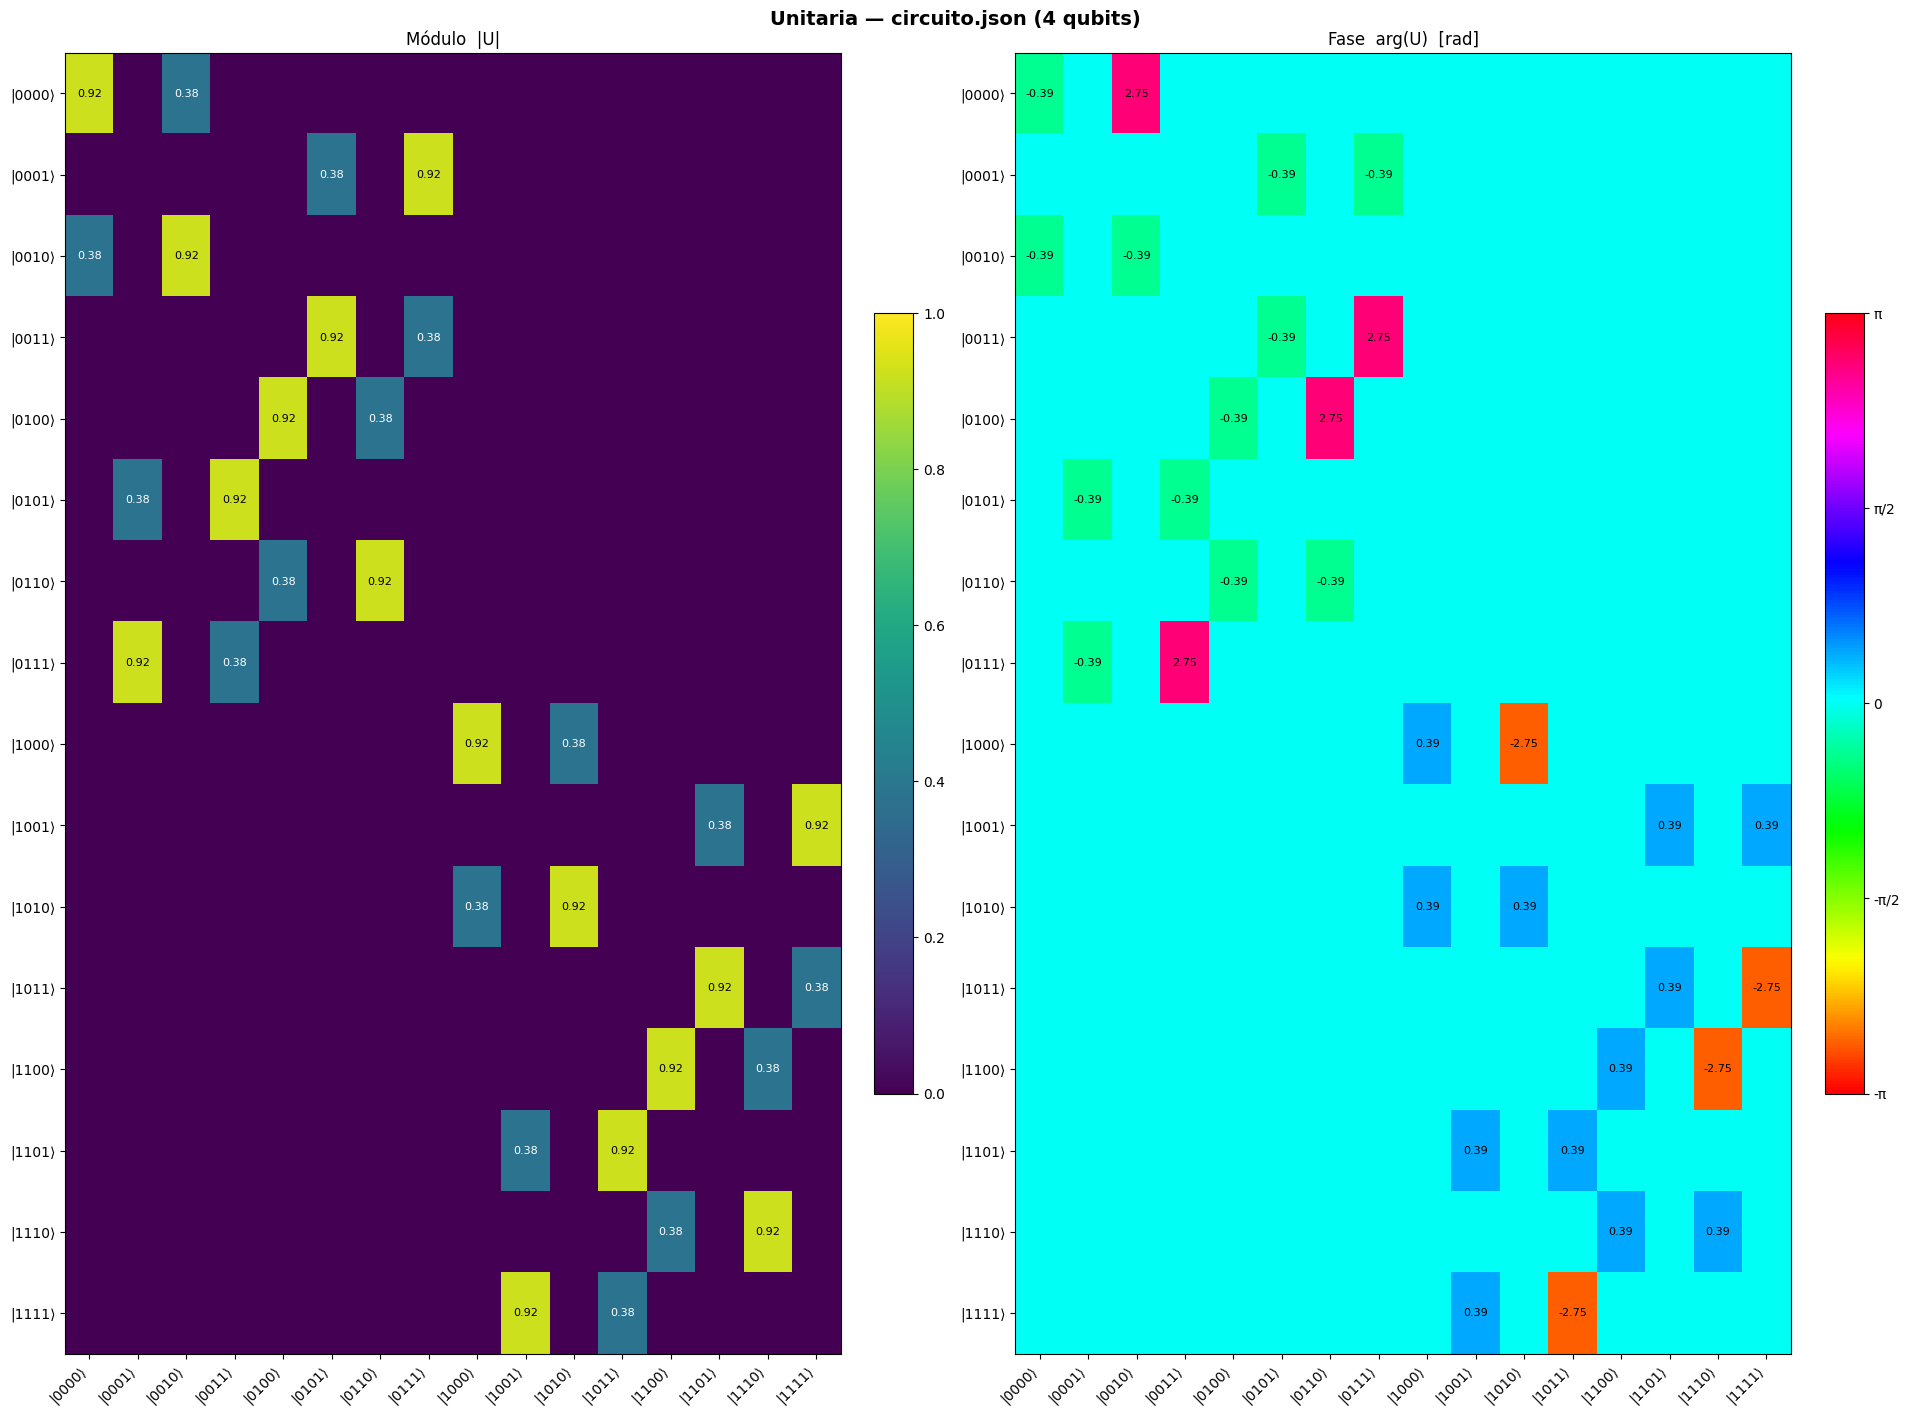

In [10]:
plot_unitary(U1, title="Unitaria — circuito.json (4 qubits)")

In [11]:
# ── Demo are_equivalent ──────────────────────────────────────────────────────
# CNOT·(H⊗I) == Bell circuit?
qc_a = QuantumCircuit(2); qc_a.h(0); qc_a.cx(0, 1)
qc_b = QuantumCircuit(2); qc_b.h(0); qc_b.cx(0, 1)  # circuito idéntico
qc_c = QuantumCircuit(2); qc_c.cx(0, 1); qc_c.h(0)  # orden distinto

print(f"qc_a == qc_b (idénticos):      {are_equivalent(qc_a, qc_b)}")
print(f"qc_a == qc_c (orden distinto): {are_equivalent(qc_a, qc_c)}")

# ── Demo unitary_to_json ─────────────────────────────────────────────────────
out = unitary_to_json(U_bell, "bell_unitary.json")
print(f"\n💾 Unitaria exportada a: {out.resolve()}")

qc_a == qc_b (idénticos):      True
qc_a == qc_c (orden distinto): False

💾 Unitaria exportada a: C:\Users\palob\Program\Quantum\json2quantum\bell_unitary.json
